In [2]:
import os
import librosa
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras import models, layers
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
file_path = Path("D:/Projects/RAVDASS/dataset/audio_speech_actors_01-24")
records = []

Function to extract features one by one and make a hstack from them. size of each feature ->
ZCR -> (1,)
Chroma STFT -> (12,)
MFCC -> (20,)
RMS Energy -> (1,)
Mel -> (128,) [Mean of the 2d data]
Total size for each audio file -> (162,)

In [4]:
def get_features(path):
    data, sample_rate = librosa.load(path) #offset to skip leading silence
    # data, sample_rate = librosa.load(path, duration=2.5, offset=0.6) #offset to skip leading silence
    result = np.array([])
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=data).T, axis=0)
    stft = np.abs(librosa.stft(data))
    chroma_stft = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T, axis=0)
    mfcc = np.mean(librosa.feature.mfcc(y=data, sr=sample_rate).T, axis=0)
    rms = np.mean(librosa.feature.rms(y=data).T, axis=0)
    mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sample_rate).T, axis=0)
    result = np.array(np.hstack([zcr, chroma_stft, mfcc, rms, mel]))
    return result

Generates Dataframe with Emotion and File location

In [5]:
for file in file_path.rglob("*.wav"):

    emotion = int(file.stem.split("-")[2])
    records.append({
    "file_path": file,
    "emotion": emotion,
    })

df = pd.DataFrame(records)
df.head()


,file_path,emotion
0,D:\Projects\RAVDASS\dataset\audio_speech_actor...,1
1,D:\Projects\RAVDASS\dataset\audio_speech_actor...,1
2,D:\Projects\RAVDASS\dataset\audio_speech_actor...,1
3,D:\Projects\RAVDASS\dataset\audio_speech_actor...,1
4,D:\Projects\RAVDASS\dataset\audio_speech_actor...,2


Generates a list (X) with all 162 feature elements and another list (Y) with corresponding Emotion

In [6]:
X, Y = [], []
for path, emotion in (df[["file_path", "emotion"]].values):
    features = get_features(path)
    for f in features:
        X.append(f)
        Y.append(emotion)

X = np.array(X)
Y = np.array(Y)
print("Feature array shape:", X.shape)
print("Labels array shape:", Y.shape)

Feature array shape: (233280,)
Labels array shape: (233280,)


Generate the feature value and emotion dataframe and save it as a .csv file

In [7]:
Features = pd.DataFrame(X)
Features['labels'] = Y
Features.columns = ['value', 'labels']
Features.head()
os.makedirs('EmotionData', exist_ok=True)
Features.to_csv(os.path.join('EmotionData', "data.csv"), index=False)

X_img = X.squeeze().reshape(-1, 9, 18, 1)
print(X_img.shape)

y_img = np.array([])
i = 0
for n in Y:
    if i%162 == 0:
        y_img = np.append(y_img, n)
    i += 1

print(y_img.shape)

(1440, 9, 18, 1)
(1440,)


Splitting dataset into Training(80%), Testing(10%) and Validation(10%) set.

In [8]:
           
X_train, X_test_with_valid, y_train, y_test_with_valid = train_test_split(
    X_img, y_img,
    test_size=0.2,        
    random_state=42,      
    shuffle=True
)

print("Training set size:", X_train.shape[0])

X_valid, X_test, y_valid, y_test = train_test_split(
    X_test_with_valid, y_test_with_valid,
    test_size=0.5,        
    random_state=42,      
    shuffle=True
)
print("Validation set size:", X_valid.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 1152
Validation set size: 144
Test set size: 144


In [9]:
import numpy as np
print("Unique labels in y_img:", np.unique(y_img))

Unique labels in y_img: [1. 2. 3. 4. 5. 6. 7. 8.]


In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu',
                           input_shape=(9, 18, 1)),
    tf.keras.layers.MaxPooling2D((1,2)),
    tf.keras.layers.Reshape((7, 256)),
    tf.keras.layers.LSTM(64, return_sequences=True, dropout=0.2),
    tf.keras.layers.LSTM(32, return_sequences=True, dropout=0.2),
    tf.keras.layers.LSTM(16, dropout=0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(8, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\riyan\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 7, 16, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 7, 64)          │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 7, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,856 (386.16 KB)

 Trainable params: 98,856 (386.16 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Shift labels from 1-8 to 0-7
#0 = neutral, 1 = calm, 2 = happy, 3 = sad, 4 = angry, 5 = fearful, 6 = disgust, 7 = surprised
y_img = y_img - 1
y_valid = y_valid - 1
y_test = y_test - 1

Checking for all label values

In [12]:
print("Unique labels in y_img:", np.unique(y_img))

Unique labels in y_img: [0. 1. 2. 3. 4. 5. 6. 7.]


In [31]:
history = model.fit(X_img, y_img, epochs=150, validation_data=(X_valid, y_valid))
model.evaluate(X_test, y_test)

Epoch 1/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.1694 - loss: 2.0430 - val_accuracy: 0.2292 - val_loss: 1.9546
Epoch 2/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2139 - loss: 1.9565 - val_accuracy: 0.2431 - val_loss: 1.8950
Epoch 3/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2313 - loss: 1.9097 - val_accuracy: 0.2708 - val_loss: 1.8414
Epoch 4/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2681 - loss: 1.8583 - val_accuracy: 0.3542 - val_loss: 1.7745
Epoch 5/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2736 - loss: 1.8140 - val_accuracy: 0.3194 - val_loss: 1.6934
Epoch 6/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3118 - loss: 1.7751 - val_accuracy: 0.4028 - val_loss: 1.5869
Epoch 7/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3361 - loss: 1.7395 - val_accuracy: 0.3958 - val_loss: 1.5840
Epoch 8/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3375 - loss: 1.6960 - val_accuracy: 0.4375 - 

[0.02990112081170082, 0.9930555820465088]

1. Get predictions for the test set
2. Convert probabilities to class indices (0-7)
3. Convert indices back to original labels (1-8) and names

In [13]:
print(X_test.shape)
# Define emotion mapping
emotion_map = {
    1: "neutral", 2: "calm", 3: "happy", 4: "sad",
    5: "angry", 6: "fearful", 7: "disgust", 8: "surprised"
}

predictions = model.predict(X_test)

predicted_indices = np.argmax(predictions, axis=1)

for i in range(144):
    pred_label = predicted_indices[i] + 1
    actual_label = y_test[i] + 1
    
    print(f"Sample {i}: Predicted: {emotion_map[pred_label]} | Actual: {emotion_map[actual_label]}")

(144, 9, 18, 1)
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
Sample 0: Predicted: neutral | Actual: calm
Sample 1: Predicted: neutral | Actual: sad
Sample 2: Predicted: neutral | Actual: sad
Sample 3: Predicted: neutral | Actual: calm
Sample 4: Predicted: neutral | Actual: fearful
Sample 5: Predicted: neutral | Actual: calm
Sample 6: Predicted: neutral | Actual: calm
Sample 7: Predicted: neutral | Actual: angry
Sample 8: Predicted: neutral | Actual: surprised
Sample 9: Predicted: neutral | Actual: fearful
Sample 10: Predicted: neutral | Actual: disgust
Sample 11: Predicted: neutral | Actual: fearful
Sample 12: Predicted: neutral | Actual: fearful
Sample 13: Predicted: neutral | Actual: happy
Sample 14: Predicted: neutral | Actual: calm
Sample 15: Predicted: neutral | Actual: angry
Sample 16: Predicted: neutral | Actual: calm
Sample 17: Predicted: neutral | Actual: sad
Sample 18: Predicted: neutral | Actual: disgust
Sample 19: Predicted: neutral | Actual: calm
Sample 20: Predicted: neutral | A

1. Get predictions (probabilities) 
2. Convert probabilities to class indices (0-7)
3. Define names in order (Index 0 to 7)
4. Print Final Accuracy and Loss from your test evaluation
5. Generate Classification Report

In [14]:
y_pred_probs = model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

emotion_names = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]

results = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Loss: {results[0]:.4f}")
print(f"Final Test Accuracy: {results[1]:.4f}")
print("-" * 30)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=emotion_names))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Final Test Loss: 2.0837
Final Test Accuracy: 0.0625
------------------------------
Classification Report:

              precision    recall  f1-score   support

     neutral       0.06      1.00      0.12         9
        calm       0.00      0.00      0.00        22
       happy       0.00      0.00      0.00        14
         sad       0.00      0.00      0.00        21
       angry       0.00      0.00      0.00        24
     fearful       0.00      0.00      0.00        12
     disgust       0.00      0.00      0.00        20
   surprised       0.00      0.00      0.00        22

    accuracy                           0.06       144
   macro avg       0.01      0.12      0.01       144
weighted avg       0.00      0.06      0.01       144



c:\Users\riyan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\riyan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\riyan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Create the confusion matrix

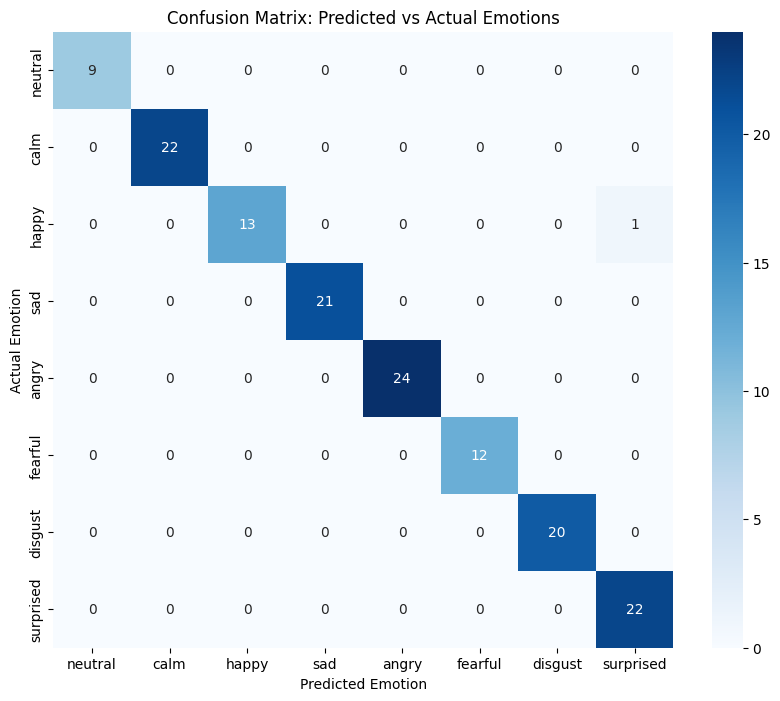

In [34]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=emotion_names, 
            yticklabels=emotion_names)

plt.title('Confusion Matrix: Predicted vs Actual Emotions')
plt.ylabel('Actual Emotion')
plt.xlabel('Predicted Emotion')
plt.show()

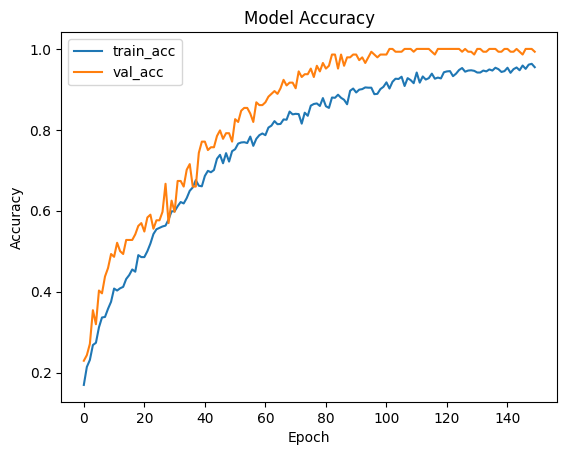

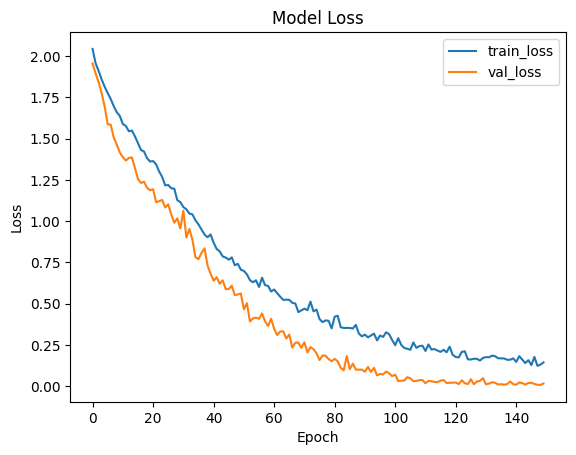

In [35]:
# 2. Plot Accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# 3. Plot Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [36]:
model.save('SER_model.keras')